In [22]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

import hyperopt as hyp

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
train_images = train_images / 255
test_images = test_images / 255

train:  (60000, 28, 28)
test:  (10000, 28, 28)


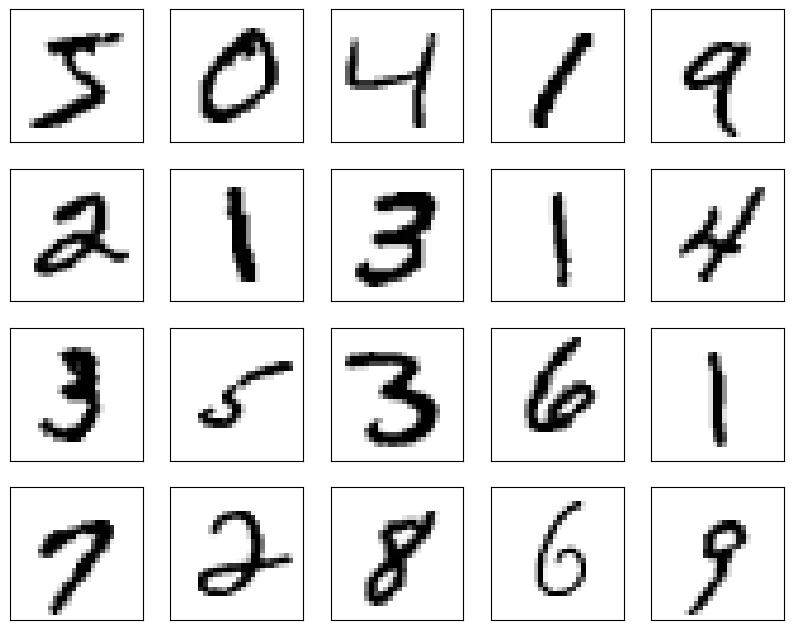

In [23]:
print('train: ', train_images.shape)
print('test: ', test_images.shape)

plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap='binary')

In [24]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(2, activation='leaky_relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5)

test_acc = model.evaluate(test_images, test_labels)
print(f'Test Accuracy: {test_acc}')

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 481us/step - accuracy: 0.4944 - loss: 1.4117
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 438us/step - accuracy: 0.6271 - loss: 1.0697
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 473us/step - accuracy: 0.6520 - loss: 1.0221
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 517us/step - accuracy: 0.6669 - loss: 0.9999
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 476us/step - accuracy: 0.6747 - loss: 0.9869
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - accuracy: 0.6896 - loss: 0.9957
Test Accuracy: [0.9957125782966614, 0.6895999908447266]


Hyperopt, setup di test

In [25]:
def train(features, labels, parameters):
    model = tf.keras.models.Sequential()

    model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
    model.add(tf.keras.layers.Dense(units=parameters['layer_size'], activation='leaky_relu'))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=parameters['learning_rate']), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(features, labels, epochs=5)

    return model

test_setup = {
    'layer_size': int(2),
    'learning_rate': 1.
}

model = train(train_images, train_labels, test_setup)
print(f'Test Acc.: {model.evaluate(test_images, test_labels)}')

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 510us/step - accuracy: 0.2848 - loss: 8.2664
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 422us/step - accuracy: 0.3122 - loss: 9.3887
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 439us/step - accuracy: 0.3089 - loss: 10.0383
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 476us/step - accuracy: 0.3143 - loss: 7.2677
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 473us/step - accuracy: 0.3179 - loss: 7.3215
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - accuracy: 0.2802 - loss: 7.2571
Test Acc.: [7.257112503051758, 0.2802000045776367]


Tuniamo iperaparamtri

In [27]:
def hyper_func(params):
    # Convert layer_size to Python int
    params['layer_size'] = int(params['layer_size'])
    
    model = train(train_images, train_labels, params)
    test = model.evaluate(test_images, test_labels)
    return {'loss': -test[1], 'status': 'ok'}

search_space = {
    'layer_size': hyp.hp.choice('layer_size', r),
    'learning_rate': hyp.hp.loguniform('learning_rate', -10, 0)
}

trials = hyp.Trials()
best = hyp.fmin(hyper_func, space=search_space, algo=hyp.tpe.suggest, max_evals=5, trials=trials)

Epoch 1/5                                            

   1/1875 ━━━━━━━━━━━━━━━━━━━━ 8:11 262ms/step - accuracy: 0.1562 - loss: 2.4207
  60/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 861us/step - accuracy: 0.2104 - loss: 2.2613  
 121/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - accuracy: 0.3352 - loss: 2.0709
 179/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 852us/step - accuracy: 0.4134 - loss: 1.9165
 233/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - accuracy: 0.4661 - loss: 1.7952
 281/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 902us/step - accuracy: 0.5026 - loss: 1.7032
 325/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 937us/step - accuracy: 0.5301 - loss: 1.6296
 337/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5368 - loss: 1.6111  
 353/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5453 - loss: 1.5874
 409/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5716 - loss: 1.5123
 464/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5932 - loss: 1.4483
 521/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6123 - loss: 1.3901
 